In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

from app.config import PLAYER_CHOICE

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import matplotlib.pyplot as plt
import numpy as np

pd.options.display.max_columns = None

In [2]:
def filter_by_players(df):
    chosen_player_matrix = None

    for name in PLAYER_CHOICE:
        current_matrix = df['PLAYER_NAME'] == name
        if chosen_player_matrix is None:
            chosen_player_matrix = current_matrix
        else:
            chosen_player_matrix = chosen_player_matrix | current_matrix

    return df[chosen_player_matrix]

In [3]:
ds = load_dataset(
    "parquet",
    data_files="https://huggingface.co/datasets/ds-training-nba/nba_shot_data/resolve/main/raw_merged/merged_dataset.parquet"
)
df = ds["train"].to_pandas()

In [4]:
df = filter_by_players(df)

In [5]:
irrelevant_cols = ['GRID_TYPE', 'SHOT_ATTEMPTED_FLAG', 'videoAvailable', 'VIDEO_AVAILABLE_FLAG']
duplicate_cols = ['actionNumber', 'clock', 'period', 'teamId', 'personId', 'playerName', 'playerNameI', 'xLegacy', 'yLegacy', 'gameId', 'EVENTNUM',
                 'PERIOD_y', 'WCTIMESTRING', 'PCTIMESTRING', 'SCORE', 'SCOREMARGIN', 'shotValue']

df_reduced = df.drop(irrelevant_cols, axis=1)
df_reduced = df_reduced.drop(duplicate_cols, axis=1)

In [6]:
cols2_drop = ['GAME_ID_x', 'GAME_EVENT_ID', 'PLAYER_ID', 'TEAM_ID', 'HTM', 'VTM', 'teamTricode', 'shotResult', 'location', 'description', 'actionType', 'subType', 'actionId',
             'HOMEDESCRIPTION', 'NEUTRALDESCRIPTION', 'VISITORDESCRIPTION', 'PLAYER1_ID', 'PLAYER1_NAME', 'PLAYER1_TEAM_ID', 'PLAYER1_TEAM_CITY', 'PLAYER1_TEAM_NICKNAME',
             'PLAYER2_ID', 'PLAYER2_NAME', 'PLAYER2_TEAM_ID', 'PLAYER2_TEAM_CITY', 'PLAYER2_TEAM_NICKNAME', 
              'PLAYER3_ID', 'PLAYER3_NAME', 'PLAYER3_TEAM_ID', 'PLAYER3_TEAM_CITY', 'PLAYER3_TEAM_NICKNAME', 'EVENT_TYPE', 'EVENTMSGACTIONTYPE', 'EVENTMSGACTIONTYPE', 'SHOT_DISTANCE',
             'EVENTMSGTYPE', 'scoreHome', 'scoreAway', 'pointsTotal', 'PERSON2TYPE', 'PLAYER2_TEAM_ABBREVIATION', 'PERSON3TYPE', 'PLAYER3_TEAM_ABBREVIATION']

df_reduced = df_reduced.drop(cols2_drop, axis=1, errors='ignore')

df_reduced.head()

,shotDistance,isFieldGoal,PLAYER_NAME,TEAM_NAME,PERIOD_x,MINUTES_REMAINING,SECONDS_REMAINING,ACTION_TYPE,SHOT_TYPE,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,LOC_X,LOC_Y,SHOT_MADE_FLAG,GAME_DATE,GAME_ID_y,PERSON1TYPE,PLAYER1_TEAM_ABBREVIATION,year,is_playoffs
1559,17,1,Kevin Garnett,Minnesota Timberwolves,1.0,9.0,41.0,Jump Shot,2PT Field Goal,Mid-Range,Right Side(R),16-24 ft.,153.0,78.0,1.0,19961101.0,29600008.0,4.0,MIN,1996,False
1568,18,1,Kevin Garnett,Minnesota Timberwolves,1.0,7.0,42.0,Jump Shot,2PT Field Goal,Mid-Range,Left Side Center(LC),16-24 ft.,-114.0,142.0,1.0,19961101.0,29600008.0,4.0,MIN,1996,False
1578,0,1,Kevin Garnett,Minnesota Timberwolves,1.0,5.0,8.0,Tip Shot,2PT Field Goal,Restricted Area,Center(C),Less Than 8 ft.,0.0,0.0,0.0,19961101.0,29600008.0,4.0,MIN,1996,False
1609,17,1,Kevin Garnett,Minnesota Timberwolves,2.0,11.0,23.0,Jump Shot,2PT Field Goal,Mid-Range,Left Side(L),16-24 ft.,-151.0,80.0,0.0,19961101.0,29600008.0,4.0,MIN,1996,False
1626,15,0,Kevin Garnett,Minnesota Timberwolves,2.0,NaN,NaN,Free Throw,1PT Free Throw,Mid-Range,Center(C),8-16 ft.,0.0,15.0,1.0,NaN,29600008.0,4.0,MIN,1996,False


In [7]:
# drop all nans in SHOT_MADE_FLAG
df_reduced.dropna(subset='SHOT_MADE_FLAG', inplace=True)

In [8]:
df_reduced.info()

<class 'pandas.DataFrame'>
Index: 556754 entries, 1559 to 8204391
Data columns (total 21 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   shotDistance               556754 non-null  int64  
 1   isFieldGoal                556754 non-null  int64  
 2   PLAYER_NAME                556754 non-null  str    
 3   TEAM_NAME                  556754 non-null  str    
 4   PERIOD_x                   556754 non-null  float64
 5   MINUTES_REMAINING          410654 non-null  float64
 6   SECONDS_REMAINING          410654 non-null  float64
 7   ACTION_TYPE                556754 non-null  str    
 8   SHOT_TYPE                  556754 non-null  str    
 9   SHOT_ZONE_BASIC            556754 non-null  str    
 10  SHOT_ZONE_AREA             556754 non-null  str    
 11  SHOT_ZONE_RANGE            556754 non-null  str    
 12  LOC_X                      556754 non-null  float64
 13  LOC_Y                      556754 non-nul

In [9]:
df_reduced.columns

Index(['shotDistance', 'isFieldGoal', 'PLAYER_NAME', 'TEAM_NAME', 'PERIOD_x',
       'MINUTES_REMAINING', 'SECONDS_REMAINING', 'ACTION_TYPE', 'SHOT_TYPE',
       'SHOT_ZONE_BASIC', 'SHOT_ZONE_AREA', 'SHOT_ZONE_RANGE', 'LOC_X',
       'LOC_Y', 'SHOT_MADE_FLAG', 'GAME_DATE', 'GAME_ID_y', 'PERSON1TYPE',
       'PLAYER1_TEAM_ABBREVIATION', 'year', 'is_playoffs'],
      dtype='str')

In [10]:
df_reduced['SHOT_MADE_FLAG'].unique()

array([1., 0.])

In [11]:
df_reduced.dropna(inplace=True)
data = df_reduced.drop('SHOT_MADE_FLAG', axis=1)
target = df_reduced['SHOT_MADE_FLAG']

In [12]:
target.unique()

array([1., 0.])

In [13]:
categorical_cols = ['isFieldGoal', 'PLAYER_NAME', 'TEAM_NAME', 'PERIOD_x', 'ACTION_TYPE', 'SHOT_TYPE', 'SHOT_ZONE_BASIC', 'SHOT_ZONE_AREA', 'SHOT_ZONE_RANGE',
                   'PERSON1TYPE', 'PLAYER1_TEAM_ABBREVIATION', 'is_playoffs']

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
data_cat = encoder.fit_transform(data[categorical_cols])

In [14]:
# 1. Get non-categorical (numerical) part
data_num = data.drop(columns=categorical_cols)

# 2. Turn encoded array into DataFrame
cat_feature_names = encoder.get_feature_names_out(categorical_cols)

data_cat_df = pd.DataFrame(
    data_cat,
    columns=cat_feature_names,
    index=data.index  # VERY important to align rows
)

# 3. Combine
data_final = pd.concat([data_num, data_cat_df], axis=1)

In [15]:
data_num.head()

,shotDistance,MINUTES_REMAINING,SECONDS_REMAINING,LOC_X,LOC_Y,GAME_DATE,GAME_ID_y,year
1559,17,9.0,41.0,153.0,78.0,19961101.0,29600008.0,1996
1568,18,7.0,42.0,-114.0,142.0,19961101.0,29600008.0,1996
1578,0,5.0,8.0,0.0,0.0,19961101.0,29600008.0,1996
1609,17,11.0,23.0,-151.0,80.0,19961101.0,29600008.0,1996
1638,12,4.0,11.0,107.0,43.0,19961101.0,29600008.0,1996


# PCA

In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_num.dropna())

In [17]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [18]:
print(pca.explained_variance_ratio_)

[0.27366837 0.21068832]


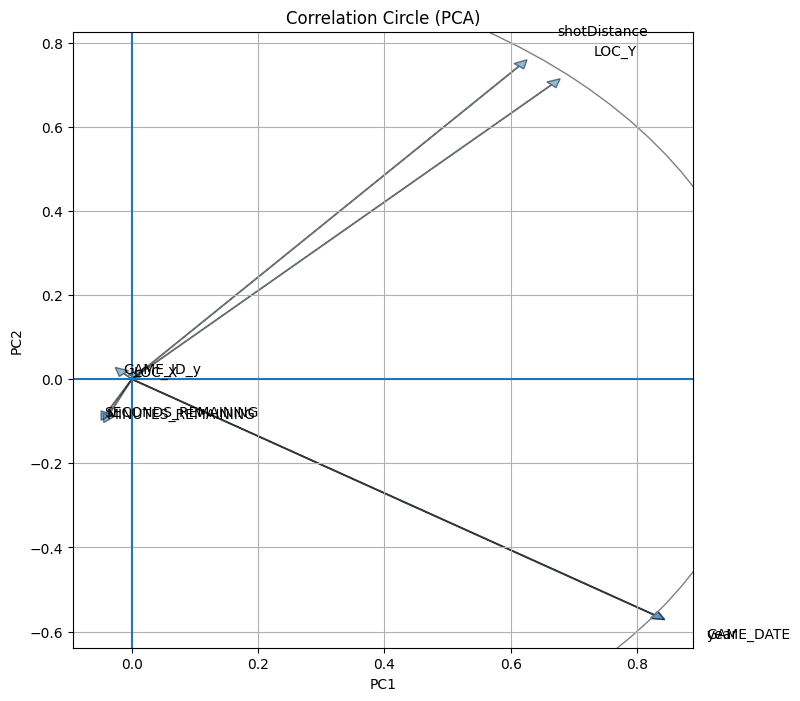

In [19]:
# Loadings (correlation between variables and PCs)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

plt.figure(figsize=(8,8))

for i, col in enumerate(data_num.columns):
    plt.arrow(0, 0, loadings[i, 0], loadings[i, 1], 
              head_width=0.02, head_length=0.02, alpha=0.5)
    plt.text(loadings[i, 0]*1.1, loadings[i, 1]*1.1, col)

# Circle
circle = plt.Circle((0,0), 1, color='gray', fill=False)
plt.gca().add_artist(circle)

plt.axhline(0)
plt.axvline(0)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Correlation Circle (PCA)')
plt.grid()
plt.show()

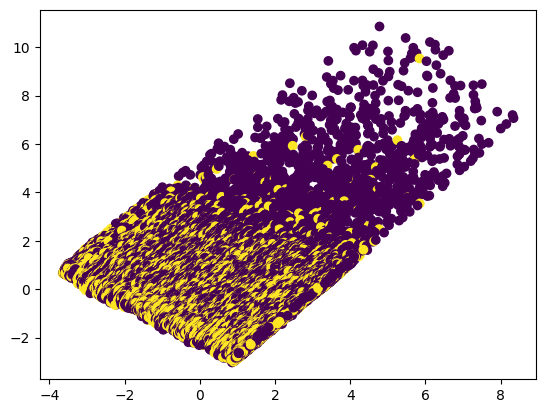

In [22]:
plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=target)
plt.show()

# LDA

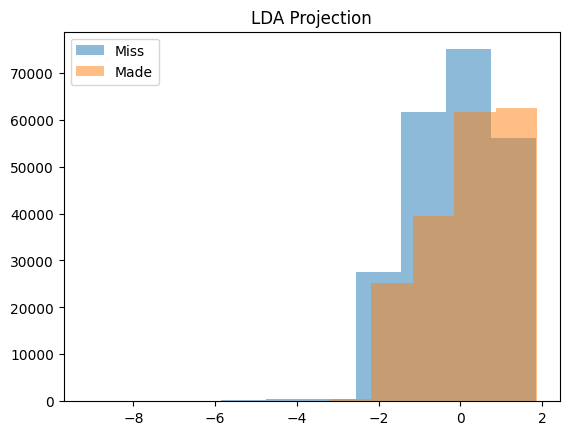

In [20]:
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X_scaled, target)

plt.hist(X_lda[target==0], alpha=0.5, label='Miss')
plt.hist(X_lda[target==1], alpha=0.5, label='Made')
plt.legend()
plt.title('LDA Projection')
plt.show()

In [21]:
importance = pd.Series(
    lda.coef_[0],
    index=data_num.columns  # or full feature list if aligned
)

importance = importance.sort_values(key=abs, ascending=False)
print(importance.head(20))

GAME_DATE            0.241715
shotDistance        -0.172274
year                -0.170976
LOC_Y               -0.154070
MINUTES_REMAINING    0.025315
SECONDS_REMAINING    0.020896
GAME_ID_y           -0.020399
LOC_X                0.015413
dtype: float64
